In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
df = pd.read_csv("../data/features.csv")

# Separate features and labels
X = df.drop('user', axis=1).values
y = df['user'].values

print(f"X shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

X shape: (75, 51)
Classes: ['Diya' 'Jash' 'Khadir' 'RITI' 'rugvedd']


In [2]:
# Encode string labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features (critical for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Label encoding:")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

Label encoding:
  0 → Diya
  1 → Jash
  2 → Khadir
  3 → RITI
  4 → rugvedd


In [3]:
# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_scores = cross_val_score(svm, X_scaled, y_encoded, cv=cv, scoring='accuracy')

print("── SVM Results ──────────────────────")
print(f"Accuracy per fold: {[f'{s:.2%}' for s in svm_scores]}")
print(f"Mean Accuracy:     {svm_scores.mean():.2%}")
print(f"Std Deviation:     {svm_scores.std():.2%}")

── SVM Results ──────────────────────
Accuracy per fold: ['100.00%', '100.00%', '93.33%', '100.00%', '100.00%']
Mean Accuracy:     98.67%
Std Deviation:     2.67%


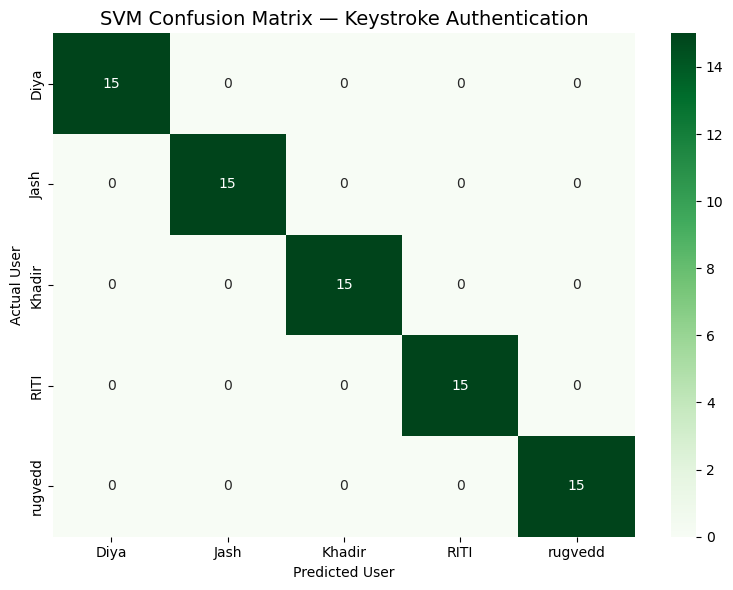


Classification Report:
              precision    recall  f1-score   support

        Diya       1.00      1.00      1.00        15
        Jash       1.00      1.00      1.00        15
      Khadir       1.00      1.00      1.00        15
        RITI       1.00      1.00      1.00        15
     rugvedd       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [6]:
# Train on full data for confusion matrix
svm.fit(X_scaled, y_encoded)
y_pred = svm.predict(X_scaled)

cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("SVM Confusion Matrix — Keystroke Authentication", fontsize=14)
plt.ylabel("Actual User")
plt.xlabel("Predicted User")
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_encoded, y_pred, target_names=le.classes_))

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y_encoded, cv=cv, scoring='accuracy')

print("── Random Forest Results ────────────")
print(f"Accuracy per fold: {[f'{s:.2%}' for s in rf_scores]}")
print(f"Mean Accuracy:     {rf_scores.mean():.2%}")
print(f"Std Deviation:     {rf_scores.std():.2%}")

── Random Forest Results ────────────
Accuracy per fold: ['100.00%', '100.00%', '100.00%', '100.00%', '100.00%']
Mean Accuracy:     100.00%
Std Deviation:     0.00%


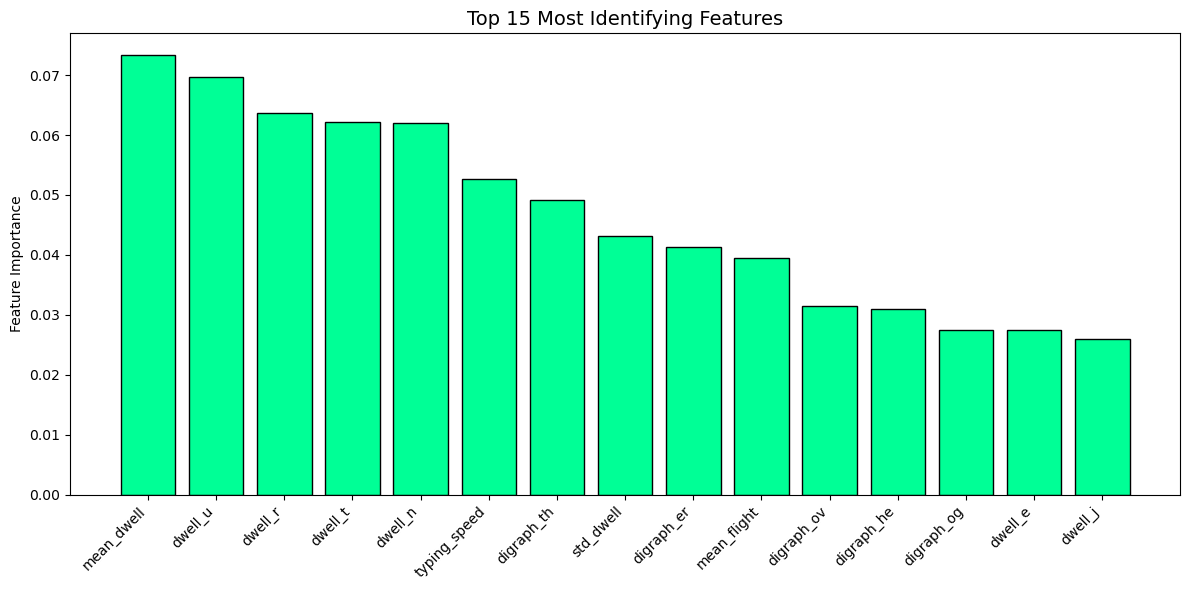

In [9]:
# Train RF on full data
rf.fit(X_scaled, y_encoded)

feature_names = df.drop('user', axis=1).columns
importances = rf.feature_importances_

# Top 15 most important features
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 6))
plt.bar(
    range(15),
    importances[top_idx],
    color='#00ff96',
    edgecolor='black'
)
plt.xticks(range(15), feature_names[top_idx], rotation=45, ha='right')
plt.title("Top 15 Most Identifying Features", fontsize=14)
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.savefig("../data/feature_importance.png", dpi=150)
plt.show()

## Finding 3 — What Identifies You Most
Contrary to initial hypothesis, mean dwell time and per-key dwell patterns
are stronger identifiers than flight time. The 'u', 'r', 't', 'n' keys
carry the most discriminating signal — likely because these are common
keys where individual finger strength and habits vary most.
Feature importance is distributed across all 51 features, confirming
that typing identity is truly multi-dimensional.

In [10]:
import pickle

# Save everything needed for the demo
with open('../models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ All models saved to models/")

✅ All models saved to models/
